# Import packages

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import numpy as np
import scipy.optimize as opt
from scipy.stats import t
# %matplotlib widget

# Inputs

In [50]:
trapped_files = [
    "Data/TEK00022.CSV",
    "Data/TEK00023.CSV",
    "Data/TEK00024.CSV",
    "Data/TEK00025.CSV",
    "Data/TEK00026.CSV",
    "Data/TEK00027.CSV",
    "Data/TEK00028.CSV",
    "Data/TEK00029.CSV",
    "Data/TEK00030.CSV",
    "Data/TEK00031.CSV",
    "Data/TEK00032.CSV",
]
data_ranges = [
    np.s_[:1920362],
    np.s_[:],
    np.s_[:],
    np.s_[21976:],
    np.s_[:],
    np.s_[:1924797],
    np.s_[536492:],
    np.s_[:1915926],
    np.s_[:1831652],
    np.s_[:],
    np.s_[15323:1534475],
]
data_laser_intensities = [
    0.42,
    0.44,
    0.46,
    0.48,
    0.50,
    0.52,
    0.54,
    0.56,
    0.58,
    0.60,
    0.61,
]
noise_files = [
    "Data/TEK00033.CSV",
    "Data/TEK00034.CSV",
    "Data/TEK00035.CSV",
]
noise_ranges = [
    np.s_[39718:1924797],
    np.s_[:1915926],
    np.s_[33064:1918144],
]
use_welch = False # Use Welch's method for PSD calculation (True) or FFT (False)
nperseg = 2**15 # Used for scipy.signal.welch PSD calculation
T = 297 # Kelvin
eta = 0.00089 # Viscosity of water (dependent on temperature)
r = 1 # Radius of spheres in micrometers (assumed to all be 1)
min_freq, max_freq = 10, 1000 # Min and max frequencies (exclusive) for plotting and calculations after FFT
sampling_rate = 31200 # Hz
seconds_per_chunk = 1 # Number of seconds to chunk data into

In [51]:
assert len(trapped_files) == len(data_ranges) == len(data_laser_intensities), f"Lengths: {len(trapped_files)}, {len(data_ranges)}, {len(data_laser_intensities)}"

# Load, chunk, and de-mean data

In [52]:
# Read data files
trapped_data_list = [pd.read_csv(data_file, skiprows=15) for data_file in trapped_files]
noise_data_list = [pd.read_csv(noise_file, skiprows=15) for noise_file in noise_files]

# Extract data ranges
trapped_data_list = [data[data_range] for data, data_range in zip(trapped_data_list, data_ranges)]
noise_data_list = [noise[noise_range] for noise, noise_range in zip(noise_data_list, noise_ranges)]

In [53]:
# Print length of each data in seconds
for i, data in enumerate(trapped_data_list):
    print(f"Trapped {i}: {len(data) / sampling_rate:.2f} seconds and {len(data)} samples")

Trapped 0: 61.55 seconds and 1920362 samples
Trapped 1: 64.10 seconds and 2000000 samples
Trapped 2: 64.10 seconds and 2000000 samples
Trapped 3: 63.40 seconds and 1978024 samples
Trapped 4: 64.10 seconds and 2000000 samples
Trapped 5: 61.69 seconds and 1924797 samples
Trapped 6: 46.91 seconds and 1463508 samples
Trapped 7: 61.41 seconds and 1915926 samples
Trapped 8: 58.71 seconds and 1831652 samples
Trapped 9: 64.10 seconds and 2000000 samples
Trapped 10: 48.69 seconds and 1519152 samples


In [54]:
# # Plot trapped data
# if trapped_data_list:
#     fig, axs = plt.subplots(len(trapped_data_list), 1, figsize=(10, 5 * len(trapped_data_list)), squeeze=False)
#     for ax, df in zip(axs[:, 0], trapped_data_list):
#         ax.plot(df['CH1'])
#         ax.set_title(f"Trapped Particle with r = {r} px")
#         ax.set_ylabel("Voltage (V)")
#     plt.tight_layout()
#     plt.show()

# # Plot noise data
# if noise_data_list:
#     fig, axs = plt.subplots(len(noise_data_list), 1, figsize=(10, 5 * len(noise_data_list)), squeeze=False)
#     for ax, df in zip(axs[:, 0], noise_data_list):
#         ax.plot(df['CH1'])
#         ax.set_title("Noise")
#         ax.set_ylabel("Voltage (V)")
#     plt.tight_layout()
#     plt.show()

In [55]:
# Copy laser intensities for each chunk of data
data_laser_intensities = [data_laser_intensity for data_laser_intensity, data in zip(data_laser_intensities, trapped_data_list) for _ in range(len(data) // (sampling_rate * seconds_per_chunk))]

# Chunk data into segments
trapped_data_list = [df.iloc[i:i+sampling_rate * seconds_per_chunk] for df in trapped_data_list for i in range(0, len(df) - len(df) % (sampling_rate * seconds_per_chunk), sampling_rate * seconds_per_chunk)]
noise_data_list = [df.iloc[i:i+sampling_rate * seconds_per_chunk] for df in noise_data_list for i in range(0, len(df) - len(df) % (sampling_rate * seconds_per_chunk), sampling_rate * seconds_per_chunk)]

In [56]:
# De-mean signals (we don't care that this also de-means the time)
trapped_data_list = [df - df.mean() for df in trapped_data_list]
noise_data_list = [df - df.mean() for df in noise_data_list]

# Plot data (just for visual inspection)

In [57]:
if False:
    # Plot trapped data
    if trapped_data_list:
        fig, axs = plt.subplots(len(trapped_data_list), 1, figsize=(10, 5 * len(trapped_data_list)), squeeze=False)
        for ax, df, r in zip(axs[:, 0], trapped_data_list):
            ax.plot(df['CH1'])
            ax.set_title(f"Trapped Particle with r = {r} px")
            ax.set_ylabel("Voltage (V)")
        plt.tight_layout()
        plt.show()

    # Plot noise data
    if noise_data_list:
        fig, axs = plt.subplots(len(noise_data_list), 1, figsize=(10, 5 * len(noise_data_list)), squeeze=False)
        for ax, df in zip(axs[:, 0], noise_data_list):
            ax.plot(df['CH1'])
            ax.set_title("Noise")
            ax.set_ylabel("Voltage (V)")
        plt.tight_layout()
        plt.show()

# Calculating FFT and PSD

In [ ]:
def get_psd(voltages, dt, total_timesteps, use_welch=use_welch, nperseg=nperseg):
    if use_welch:
        welch = signal.welch(voltages, fs=1/dt, nperseg=nperseg, scaling='density')
        freqs = welch[0]
        psd = welch[1]
    else:
        # Compute RFFT, PSD and frequency bins, sort the results by PSD
        fhat = np.fft.rfft(voltages, total_timesteps)
        psd = fhat * np.conj(fhat) / (total_timesteps * dt)
        # Adjust the PSD for the symmetry of the RFFT
        psd *= 2

        # Frequency bins for the RFFT
        freqs = np.fft.rfftfreq(total_timesteps, d=dt)

        # Verify that PSD is real
        assert np.allclose(psd, psd.real)
        psd = psd.real

    return pd.DataFrame({'Frequency': freqs, 'PSD': psd})

In [59]:
total_timesteps = sampling_rate * seconds_per_chunk # Get the total number of time steps

trapped_psd_list = [get_psd(df['CH1'], 1/sampling_rate, total_timesteps) for df in trapped_data_list]
noise_psd_list = [get_psd(df['CH1'], 1/sampling_rate, total_timesteps) for df in noise_data_list]

freqs = trapped_psd_list[0]['Frequency']

mask = freqs > min_freq  # Ignore the zero frequency
mask &= freqs < max_freq  # Ignore high frequency noise

avg_noise_psd = sum(noise_psd_list) / len(noise_psd_list)
avg_noise_psd['STD'] = np.std([df['PSD'] for df in noise_psd_list], axis=0)
difference_psd_list = [trapped_psd - avg_noise_psd for trapped_psd in trapped_psd_list]

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython.message.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/checkrc.pxd", line 13, in zmq.backend.cython.checkrc._check_rc
KeyboardInterrupt: 


In [ ]:
if False:
    # Loop through each PSD chunk
    for i, (trapped_psd, difference_psd) in enumerate(zip(trapped_psd_list, difference_psd_list)):
        # Create a new figure with 2 subplots for each chunk
        fig, axs = plt.subplots(1, 2, figsize=(12, 6))

        # Left subplot: Trapped PSD with average noise
        ax = axs[0]
        ax.plot(freqs[mask], trapped_psd['PSD'][mask], 'o-', markersize=5, label='Trapped PSD')
        ax.plot(freqs[mask], avg_noise_psd['PSD'][mask], 'o-', markersize=5, label='Average Noise PSD')
        ax.fill_between(
            freqs[mask],
            (avg_noise_psd['PSD'] - avg_noise_psd['STD'])[mask],
            (avg_noise_psd['PSD'] + avg_noise_psd['STD'])[mask],
            color='gray', alpha=0.3, label='Noise STD'
        )
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'Trapped PSD {i+1}')
        ax.legend()
        ax.grid(True)

        # Right subplot: Noise-subtracted PSD
        ax = axs[1]
        ax.plot(freqs[mask], difference_psd['PSD'][mask], 'o-', markersize=5, label='Noise-Subtracted PSD')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'Noise-Subtracted PSD {i+1}')
        ax.legend()
        ax.grid(True)

        plt.tight_layout()
        plt.show()

# Lorentzian fitting to PSD

In [ ]:
# Define the Lorentzian function with f0 and gamma as parameters
def lorentzian(f, gamma, f0, x2):
    return (2 * x2 * (gamma / (2 * np.pi))) / ((f - f0)**2 + (gamma / (2 * np.pi))**2)

In [ ]:
mask &= freqs > 2 # Cut off low frequencies to avoid anomalies with low frequency noise

# Compute expected x^2 for each trapped data frame
x_squared_expectation_list = [np.mean(df['CH1']**2) for df in trapped_data_list]

In [ ]:
if False:
    # Store fit parameters and covariance matrices
    fit_params_list = []
    cov_matrices_list = []

    # Loop over each trapped PSD dataset and fit the Lorentzian model
    for trapped_psd, difference_psd, x_squared_expectation in zip(trapped_psd_list, difference_psd_list, x_squared_expectation_list):
        
        # Initial guess for [Gamma, f0, x^2]
        initial_guess = [100.0, 0.0, x_squared_expectation]

        # Fit the Lorentzian function
        popt, pcov = opt.curve_fit(
            lambda f, gamma, f0, x2: lorentzian(f, gamma, f0, x2),
            freqs[mask],
            difference_psd['PSD'][mask],
            p0=initial_guess,
            maxfev=10000,
        )

        # Store results
        fit_params_list.append(popt)
        cov_matrices_list.append(pcov)

        # Extract optimal parameters
        gamma_opt, f0_opt, x2_opt = popt

        # # Create side-by-side plots
        # fig, axs = plt.subplots(1, 2, figsize=(12, 6))

        # # Plot Lorentzian fit
        # axs[0].scatter(freqs[mask], difference_psd['PSD'][mask], label="Noise-Differenced PSD Data", color="blue", s=10)
        # axs[0].plot(freqs[mask], lorentzian(freqs[mask], gamma_opt, f0_opt, x2_opt), label="Fitted Lorentzian", color="red", lw=2)
        # axs[0].set_title("Lorentzian Fit to Noise-Differenced PSD Data")
        # axs[0].set_xlabel("Frequency")
        # axs[0].set_ylabel("Power Spectral Density")
        # axs[0].set_xscale('log')
        # axs[0].set_yscale('log')
        # axs[0].legend()
        # axs[0].grid(True)

        # # Plot residuals
        # residuals = difference_psd['PSD'][mask] - lorentzian(freqs[mask], gamma_opt, f0_opt, x2_opt)
        # axs[1].scatter(freqs[mask], residuals, label="Residuals", color="blue", s=10)
        # axs[1].set_xlabel("Frequency")
        # axs[1].set_ylabel("Residual (PSD - Fit)")
        # axs[1].set_xscale('log')
        # axs[1].set_yscale('log')
        # axs[1].legend()
        # axs[1].grid(True)

        # plt.tight_layout()
        # plt.show()

# Averaging trapped PSDs

In [ ]:
kb = 1.380649e-23 # SI units

In [ ]:
def x2_expected(V2_average, f, S, r):
    return kb * T * V2_average / (6 * np.pi**3 * eta * f**2 * S * r)

def gamma_expected(V2_average, f, S):
    return np.pi**2 * f**2 * S / V2_average

def psd_expected(x2_average, gamma, f):
    return 2 * x2_average * gamma / (2 * np.pi) / (f**2 + (gamma / (2 * np.pi))**2)

[[   8404.83132165  -97595.77633143]
 [ -97595.77633143 4200800.83771728]]
Chi-square: 40.493711062271686
Reduced Chi-square: 0.041027062879707886
Fit parameters for intensity 0.42 mW:
  gamma = 1.2984e+03 ± 9.1678e+01
  f0    = 0.0000e+00 (fixed)
  x2    = 4.4302e+04 ± 2.0496e+03


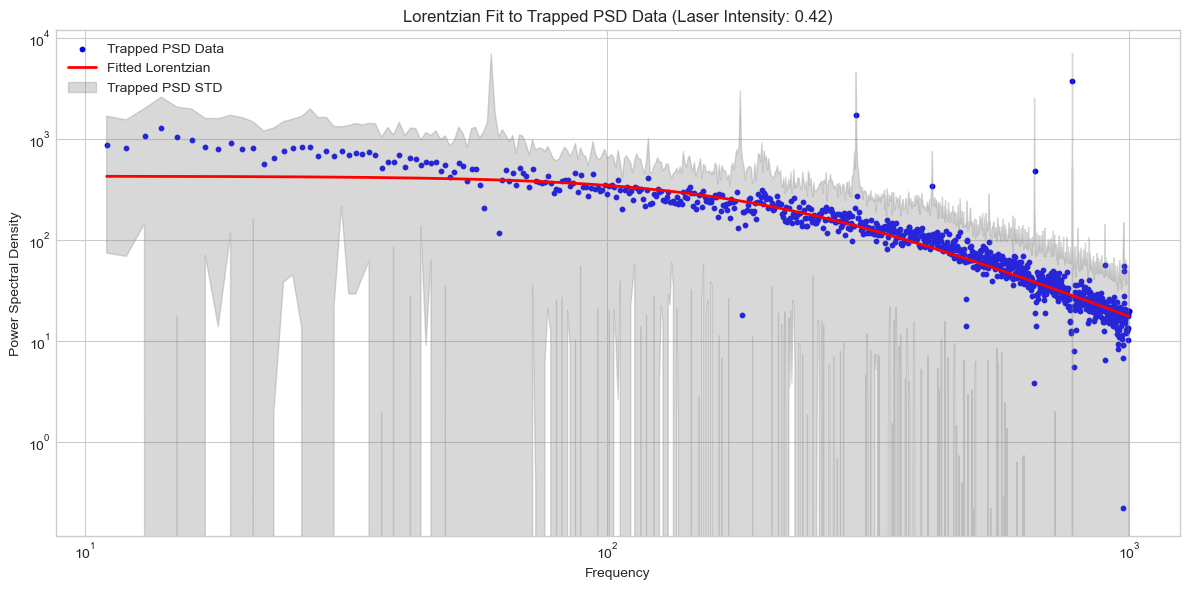

[[   8937.96353518 -118658.5154594 ]
 [-118658.5154594  4932112.85538218]]
Chi-square: 49.90689293463369
Reduced Chi-square: 0.05056422789729857
Fit parameters for intensity 0.44 mW:
  gamma = 1.2830e+03 ± 9.4541e+01
  f0    = 0.0000e+00 (fixed)
  x2    = 4.6545e+04 ± 2.2208e+03


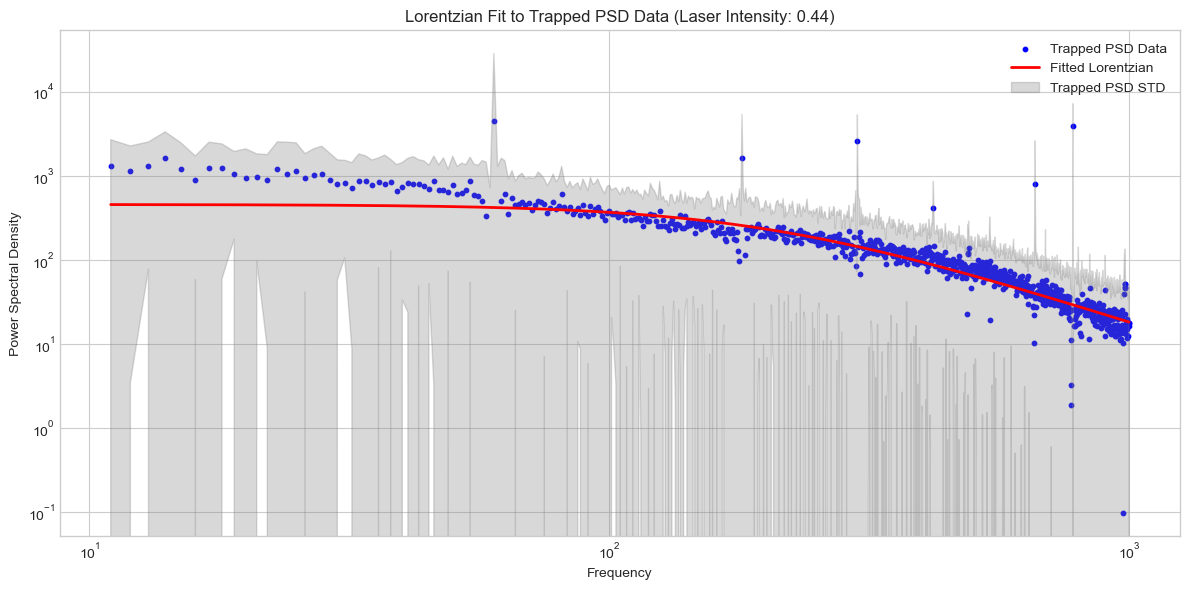

[[   9038.09605828 -111666.38105642]
 [-111666.38105642 4578564.84195922]]
Chi-square: 48.79163118840022
Reduced Chi-square: 0.04943427678662636
Fit parameters for intensity 0.46 mW:
  gamma = 1.3128e+03 ± 9.5069e+01
  f0    = 0.0000e+00 (fixed)
  x2    = 4.5657e+04 ± 2.1398e+03


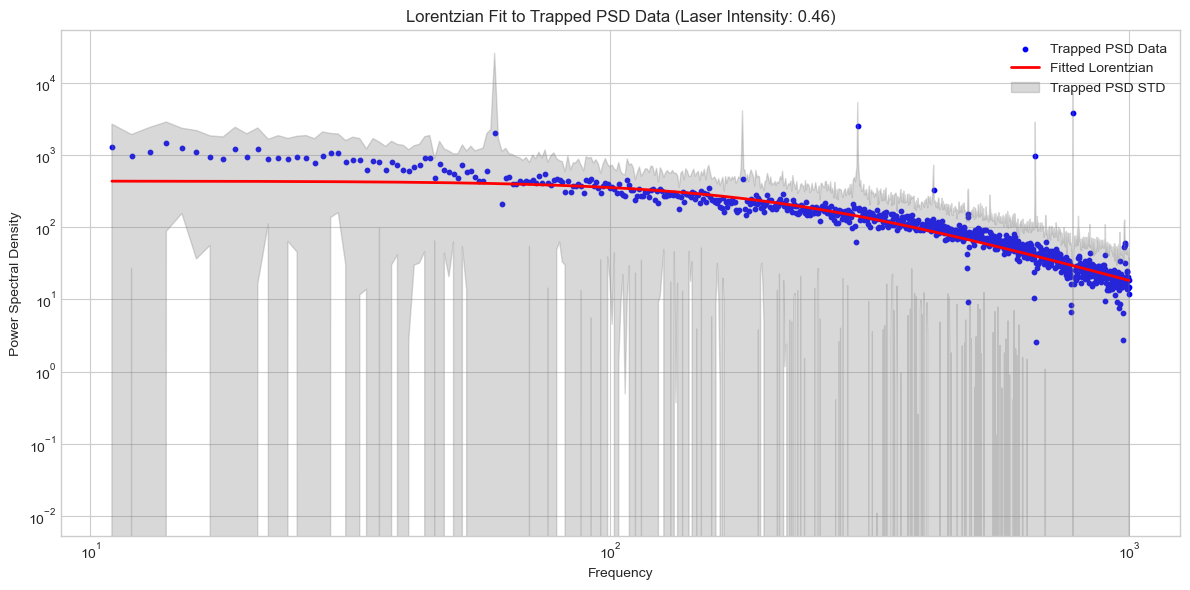

[[  10680.81604492  -90488.39281704]
 [ -90488.39281704 3456682.76517529]]
Chi-square: 50.49531329408848
Reduced Chi-square: 0.051160398474253785
Fit parameters for intensity 0.48 mW:
  gamma = 1.4329e+03 ± 1.0335e+02
  f0    = 0.0000e+00 (fixed)
  x2    = 4.0945e+04 ± 1.8592e+03


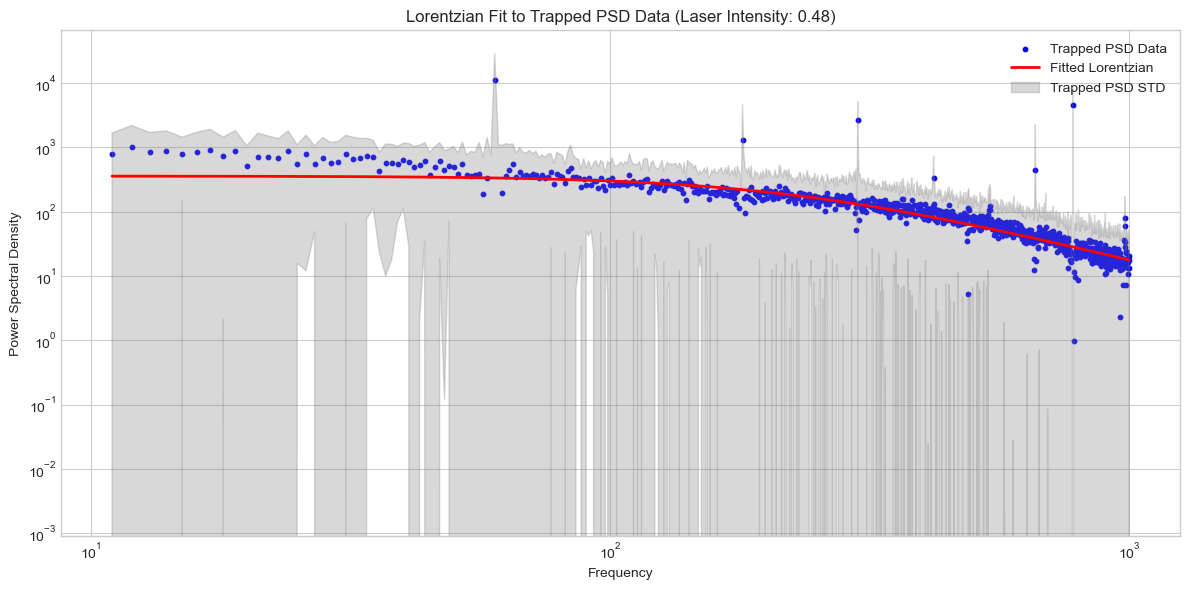

[[  13298.60815937  -72937.07020316]
 [ -72937.07020316 2711386.19270841]]
Chi-square: 29.017268545785893
Reduced Chi-square: 0.029399461545882362
Fit parameters for intensity 0.5 mW:
  gamma = 1.6391e+03 ± 1.1532e+02
  f0    = 0.0000e+00 (fixed)
  x2    = 3.8502e+04 ± 1.6466e+03


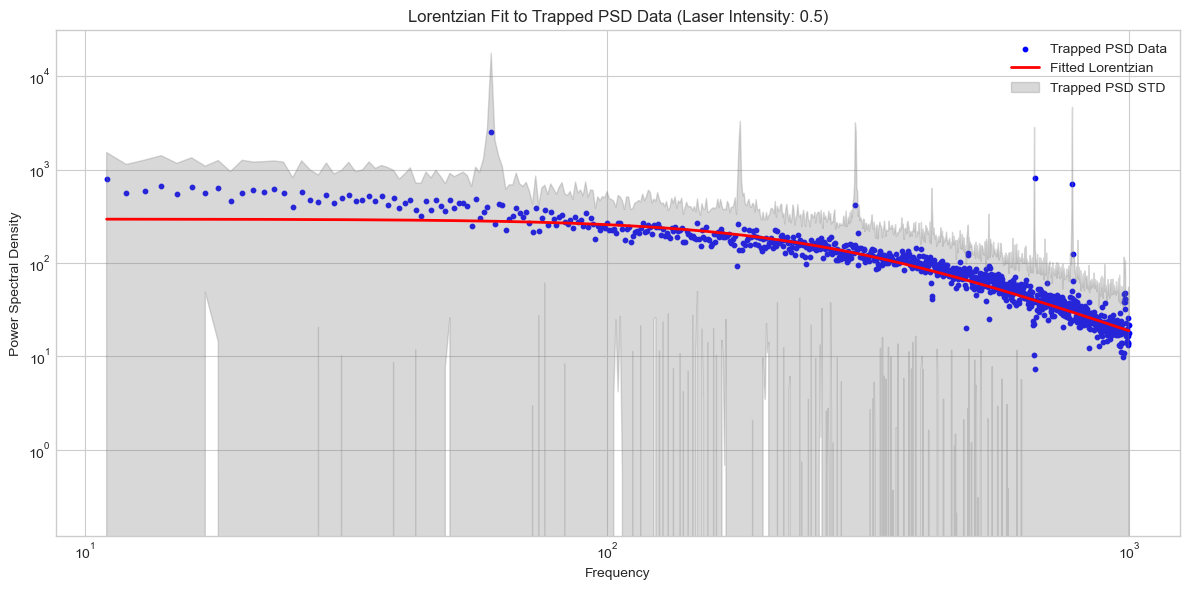

[[  14319.81853491  -55264.2924659 ]
 [ -55264.2924659  2233782.14088519]]
Chi-square: 38.033155374028965
Reduced Chi-square: 0.0385340986565643
Fit parameters for intensity 0.52 mW:
  gamma = 1.7247e+03 ± 1.1967e+02
  f0    = 0.0000e+00 (fixed)
  x2    = 3.5519e+04 ± 1.4946e+03


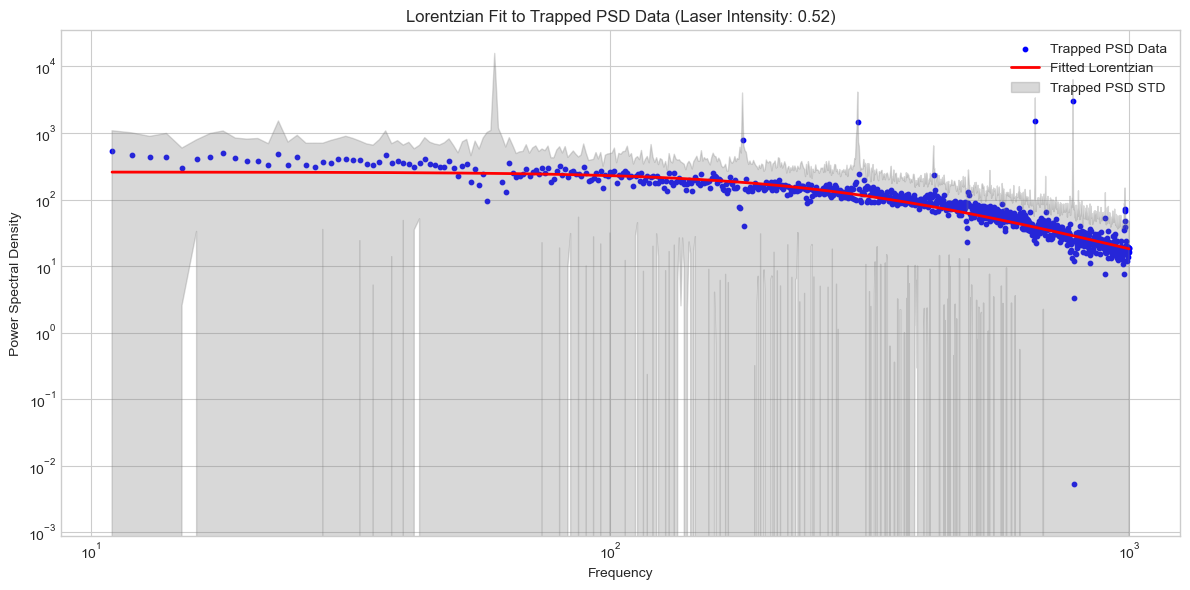

[[  17538.61965915  -37016.97180893]
 [ -37016.97180893 1675337.59312271]]
Chi-square: 43.28560566055186
Reduced Chi-square: 0.043855730152534814
Fit parameters for intensity 0.54 mW:
  gamma = 1.9056e+03 ± 1.3243e+02
  f0    = 0.0000e+00 (fixed)
  x2    = 3.1332e+04 ± 1.2943e+03


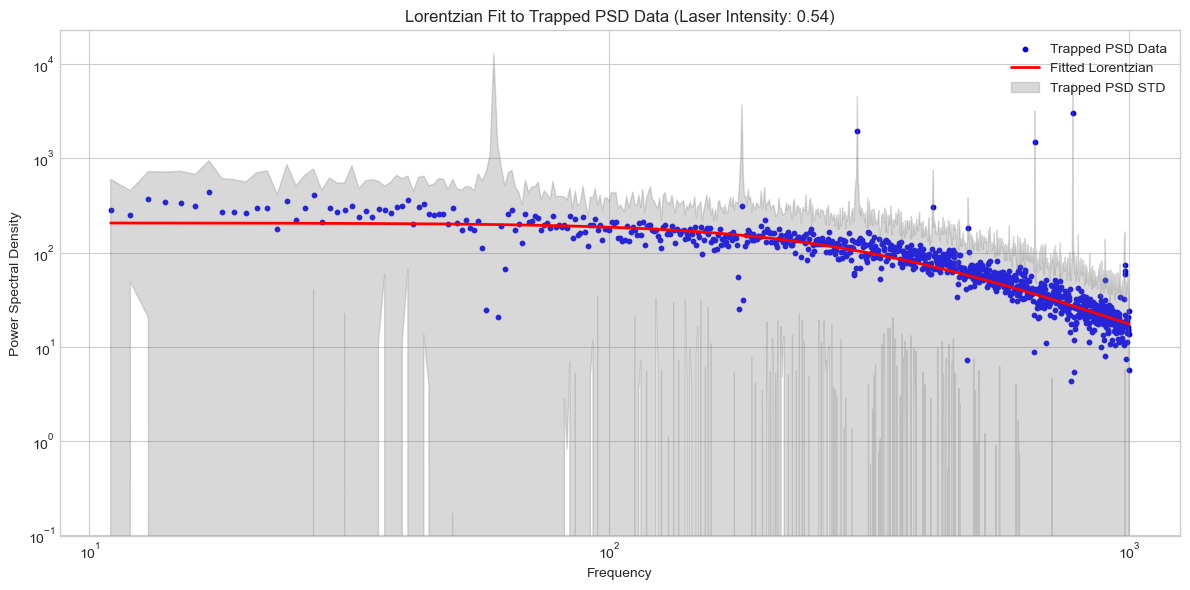

[[  17645.71429764  -33447.23257865]
 [ -33447.23257865 1679472.38921908]]
Chi-square: 28.042240798519586
Reduced Chi-square: 0.02841159148786179
Fit parameters for intensity 0.56 mW:
  gamma = 1.9272e+03 ± 1.3284e+02
  f0    = 0.0000e+00 (fixed)
  x2    = 3.1789e+04 ± 1.2959e+03


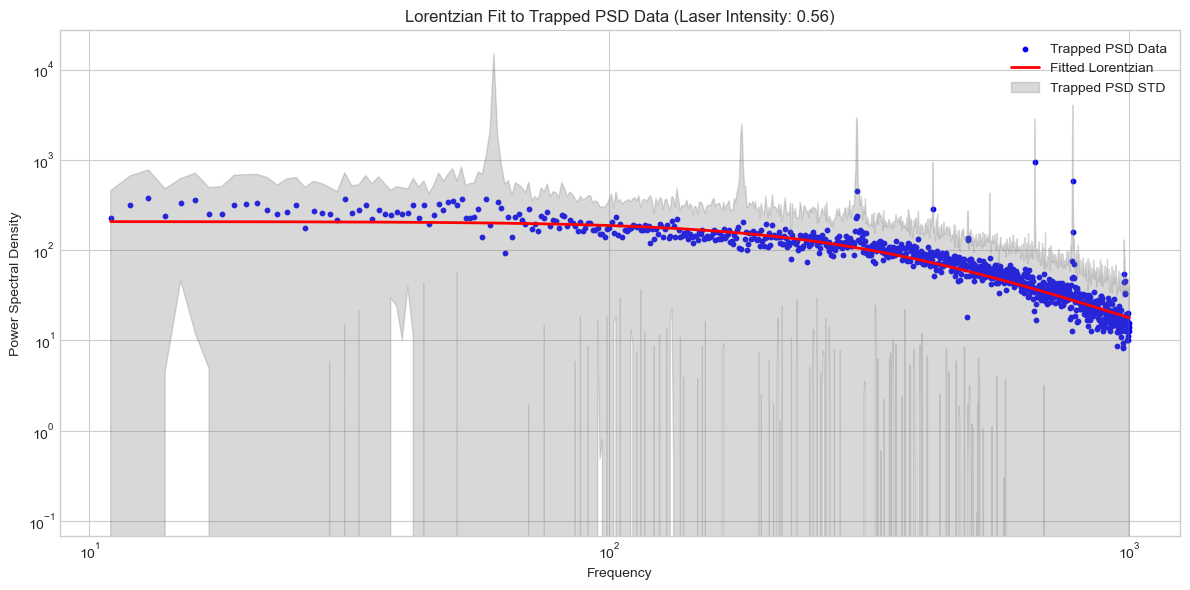

[[  16602.51901537  -50339.09772956]
 [ -50339.09772956 1879193.79257307]]
Chi-square: 47.29743737058928
Reduced Chi-square: 0.04792040260444709
Fit parameters for intensity 0.58 mW:
  gamma = 1.7972e+03 ± 1.2885e+02
  f0    = 0.0000e+00 (fixed)
  x2    = 3.2288e+04 ± 1.3708e+03


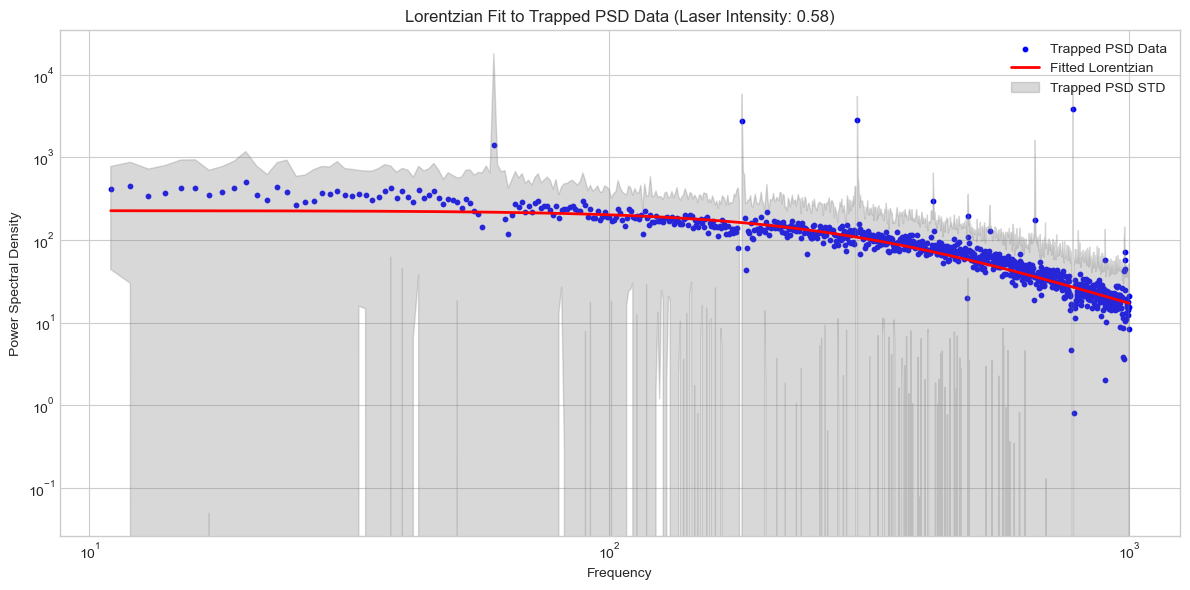

[[  14602.57801068  -66382.92250656]
 [ -66382.92250656 2142544.24530771]]
Chi-square: 31.019259037888812
Reduced Chi-square: 0.03142782070708086
Fit parameters for intensity 0.6 mW:
  gamma = 1.6411e+03 ± 1.2084e+02
  f0    = 0.0000e+00 (fixed)
  x2    = 3.3738e+04 ± 1.4637e+03


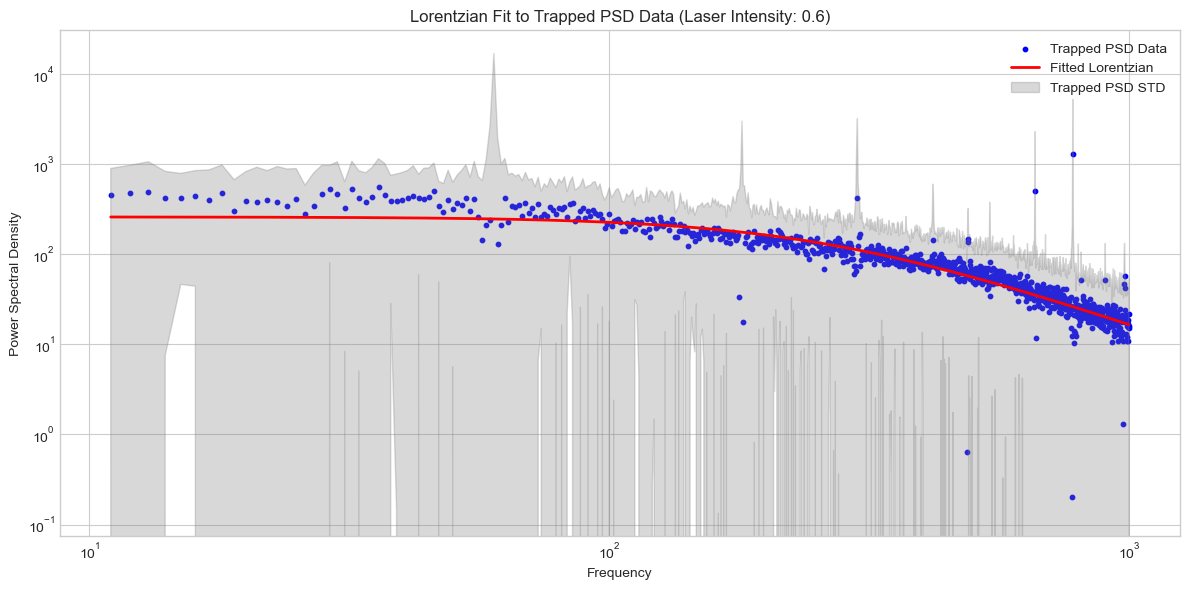

[[  23885.02048609   -9758.00418243]
 [  -9758.00418243 1340025.77599385]]
Chi-square: 33.54098764490945
Reduced Chi-square: 0.03398276357133683
Fit parameters for intensity 0.61 mW:
  gamma = 2.2402e+03 ± 1.5455e+02
  f0    = 0.0000e+00 (fixed)
  x2    = 2.8055e+04 ± 1.1576e+03


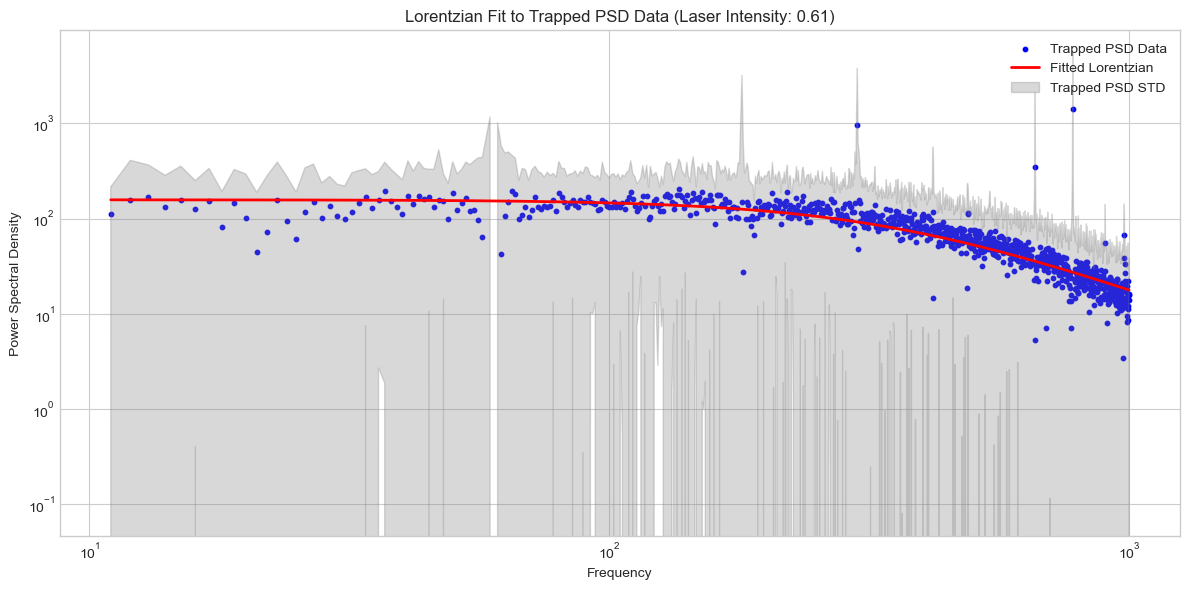

In [ ]:
# Get the unique laser intensity values (sorted)
unique_intensities = sorted(set(data_laser_intensities))

ks = []
k_errors = []  # New list to store the propagated error on k

for intensity in unique_intensities:
    # Find indices for this intensity (lists are aligned)
    indices = [i for i, I in enumerate(data_laser_intensities) if I == intensity]
    
    # Group the corresponding PSDs and x² expectations
    group_psd = [trapped_psd_list[i] for i in indices]
    group_x2 = [x_squared_expectation_list[i] for i in indices]
    
    # Average the trapped PSDs and compute STD for the group
    avg_trapped_psd = sum(group_psd) / len(group_psd)
    avg_trapped_psd['STD'] = np.std([df['PSD'] for df in group_psd], axis=0)
    
    # Compute noise-differenced PSD and its STD in quadrature
    avg_difference_psd = avg_trapped_psd - avg_noise_psd
    avg_difference_psd['STD'] = np.sqrt(avg_trapped_psd['STD']**2 + avg_noise_psd['STD']**2)
    # avg_difference_psd = avg_trapped_psd
    # avg_difference_psd['STD'] = avg_trapped_psd['STD']
    
    # Use the average x² from the group for the initial guess; now only two parameters: gamma and x2.
    initial_guess = [100.0, np.mean(group_x2)]
    
    # Fit Lorentzian to the averaged noise-differenced PSD with f0 fixed to 0
    # The lambda now takes only gamma and x2, and passes f0 = 0 to the model.
    popt, pcov = opt.curve_fit(
        lambda f, gamma, x2: lorentzian(f, gamma, 0.0, x2),
        freqs[mask],
        avg_difference_psd['PSD'][mask],
        p0=initial_guess,
        maxfev=10000,
        sigma=avg_difference_psd['STD'][mask],
        absolute_sigma=True,
    )

    print(pcov)

    # Compute the model values using the best-fit parameters (with f0 fixed to 0)
    model_values = lorentzian(freqs[mask], popt[0], 0.0, popt[1])

    # Calculate the residuals (difference between observed data and model)
    residuals = avg_difference_psd['PSD'][mask] - model_values

    # Compute chi-square
    chi_square = np.sum((residuals / avg_difference_psd['STD'][mask])**2)

    # Optionally, compute the degrees of freedom (dof)
    dof = len(avg_difference_psd['PSD'][mask]) - len(popt)

    # And the reduced chi-square
    reduced_chi_square = chi_square / dof

    print("Chi-square:", chi_square)
    print("Reduced Chi-square:", reduced_chi_square)

    # Extract optimal parameters; now popt contains only gamma and x2, with f0 fixed to zero.
    gamma_opt, x2_opt = popt
    f0_opt = 0.0

    # Print out each fit parameter and its standard deviation
    print(f"Fit parameters for intensity {intensity} mW:")
    print(f"  gamma = {gamma_opt:.4e} ± {np.sqrt(pcov[0,0]):.4e}")
    print(f"  f0    = {f0_opt:.4e} (fixed)")
    print(f"  x2    = {x2_opt:.4e} ± {np.sqrt(pcov[1,1]):.4e}")

    # Propagate the error from gamma to k:
    # k = zeta * gamma, so the error in k is: sigma_k = zeta * sqrt(pcov[0,0])
    sigma_gamma = np.sqrt(pcov[0, 0])
    
    zeta = 6 * np.pi * eta * r  # Mobility
    k = zeta * gamma_opt       # Fit from average difference PSD
    k_err = zeta * sigma_gamma # Propagated error on k

    # Store the k value and its error
    ks.append(k)
    k_errors.append(k_err)
    
    # Plot the results for this laser intensity group
    plt.figure(figsize=(12, 6))
    plt.scatter(freqs[mask], avg_difference_psd['PSD'][mask],
                label="Trapped PSD Data", color="blue", s=10)
    plt.plot(freqs[mask], lorentzian(freqs[mask], gamma_opt, 0.0, x2_opt),
             label="Fitted Lorentzian", color="red", lw=2)
    plt.fill_between(
        freqs[mask],
        (avg_difference_psd['PSD'] - avg_difference_psd['STD'])[mask],
        (avg_difference_psd['PSD'] + avg_difference_psd['STD'])[mask],
        color='gray', alpha=0.3, label='Trapped PSD STD'
    )

    plt.title(f"Lorentzian Fit to Trapped PSD Data (Laser Intensity: {intensity})")
    plt.xlabel("Frequency")
    plt.ylabel("Power Spectral Density")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

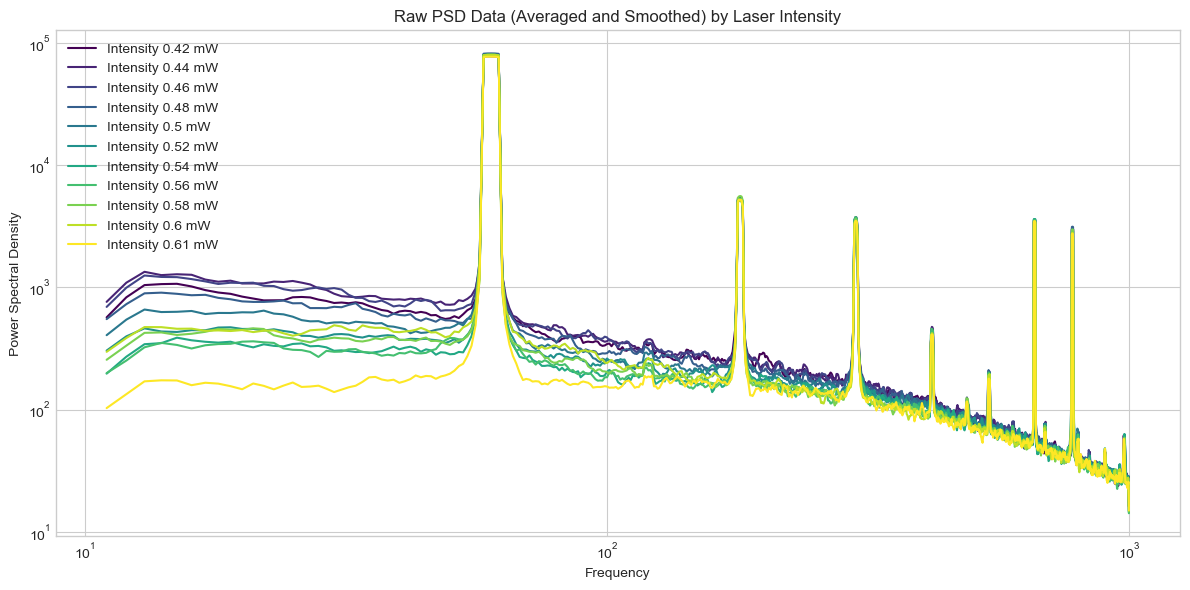

In [ ]:
plt.figure(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(unique_intensities)))
window = 5  # moving average window size

for color, intensity in zip(colors, unique_intensities):
    indices = [i for i, I in enumerate(data_laser_intensities) if I == intensity]
    
    # Extract PSD data for the current group and apply the frequency mask
    group_psd = [trapped_psd_list[i]['PSD'][mask] for i in indices]
    psd_values = np.array(group_psd)
    
    # Average the PSDs and compute the STD for this group (using masked data)
    avg_psd = np.mean(psd_values, axis=0)
    std_psd = np.std(psd_values, axis=0)
    
    # Smooth the averaged PSD and STD with a basic moving average filter
    avg_psd_smooth = np.convolve(avg_psd, np.ones(window)/window, mode='same')
    std_psd_smooth = np.convolve(std_psd, np.ones(window)/window, mode='same')
    
    # Plot the smoothed averaged PSD data using the masked freqs (so dimensions match)
    plt.plot(freqs[mask], avg_psd_smooth, label=f"Intensity {intensity} mW", color=color)
    
    # Optionally, add a shaded region for ±1 standard deviation
    # plt.fill_between(freqs[mask],
    #                  np.convolve(avg_psd - std_psd, np.ones(window)/window, mode='same'),
    #                  np.convolve(avg_psd + std_psd, np.ones(window)/window, mode='same'),
    #                  color=color, alpha=0.3)

plt.title("Raw PSD Data (Averaged and Smoothed) by Laser Intensity")
plt.xlabel("Frequency")
plt.ylabel("Power Spectral Density")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display k values

[0.03219851 0.02053725 0.08973723 0.01661307 0.07011528 0.08164808
 0.2765076  0.15306916 0.01586795 0.59386191 0.37099856]
chi square p value:  0.07831684347281742
DOF 9
chi square 15.49039140267012
chi square null hypothesis 71.84738494575024
p-value 6.605271885007369e-12
Fitted slope: 6.2577e+01
Fitted intercept: -5.3276e+00
Reduced Chi-square: 1.7212
p-value for trend (non-zero slope): 3.2507e-04


<>:53: SyntaxWarning: invalid escape sequence '\c'
<>:53: SyntaxWarning: invalid escape sequence '\c'
/var/folders/px/wy4h6r3d0pjcgpg5tm4lrp9h0000gn/T/ipykernel_55093/2840904154.py:53: SyntaxWarning: invalid escape sequence '\c'
  label=f'Weighted Fit ($\chi^2_{{red}} = {reduced_chi2:.3f}$)')


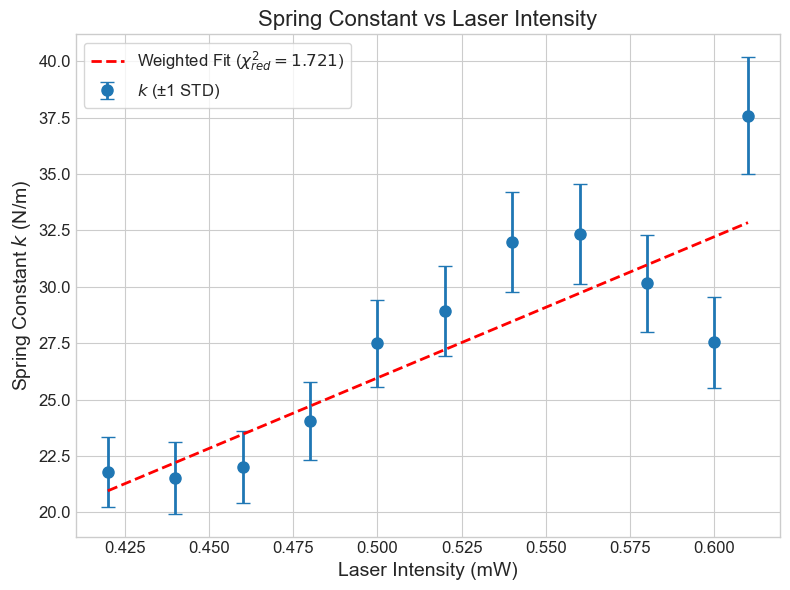

In [ ]:
# Convert k_errors (a list) to a numpy array
k_errors = np.array(k_errors)

# Define weights from the errors (inverse of variance)
weights = 1.0 / (k_errors**2)

# Perform a weighted linear least squares fit and obtain the covariance matrix
p, cov = np.polyfit(unique_intensities, ks, 1, w=weights, cov=True)
slope, intercept = p[0], p[1]

# Calculate the best-fit line
fit_line = np.polyval(p, unique_intensities)

# Compute chi-square:
# chi2 = sum((observed - predicted)^2 / sigma^2)
chi2 = np.sum(((ks - fit_line) / k_errors) ** 2)
N = len(ks)
# Reduced chi-square (with 2 fit parameters: slope and intercept)
reduced_chi2 = chi2 / (N - 2)
print((((ks - fit_line) / k_errors) ** 2) / (N - 2))

# Compute the standard error of the slope from the covariance matrix
std_err_slope = np.sqrt(cov[0, 0])

# Compute the t-statistic for the slope
t_val = slope / std_err_slope
df = N - 2  # degrees of freedom

# Compute the two-sided p-value for the null hypothesis (slope == 0)
p_value = 2 * t.sf(np.abs(t_val), df)

import scipy.stats as stats
print("chi square p value: ", 1 - stats.chi2.cdf(chi2, N - 2))
print("DOF", df)
print("chi square", chi2)

chi2_null = np.sum(((ks - np.mean(ks)) / k_errors) ** 2)
print("chi square null hypothesis", chi2_null)
print('p-value', 1 - stats.chi2.cdf(chi2_null, N - 2))

# Print the results
print(f"Fitted slope: {slope:.4e}")
print(f"Fitted intercept: {intercept:.4e}")
print(f"Reduced Chi-square: {reduced_chi2:.4f}")
print(f"p-value for trend (non-zero slope): {p_value:.4e}")

# Plot the data with error bars and the weighted fit line
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(unique_intensities, ks, yerr=k_errors, fmt='o', lw=2, markersize=8,
            capsize=5, label=r'$k$ (±1 STD)')
ax.plot(unique_intensities, fit_line, '--', lw=2, color='red',
        label=f'Weighted Fit ($\chi^2_{{red}} = {reduced_chi2:.3f}$)')
ax.set_xlabel('Laser Intensity (mW)', fontsize=14)
ax.set_ylabel(r'Spring Constant $k$ (N/m)', fontsize=14)
ax.set_title('Spring Constant vs Laser Intensity', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12, frameon=True)
plt.tight_layout()
plt.show()